# Unmixing a simulated STEM-EELS spectrum image

A spectrum image is a datacube: at every probe position of a STEM scan, a full
energy-loss spectrum. When the specimen contains a few phases, each pixel
spectrum is, to first order, a non-negative mixture of a few phase spectra
(endmembers), weighted by how much of each phase the beam crossed. Recovering
the endmembers and their abundance maps from the cube alone is the unmixing
problem, and because real maps never come with ground truth, the only way to
know how well an algorithm does is to simulate.

This notebook walks the full path: simulate a three-phase oxide scene with
exact ground truth, look at the data, choose the number of components, unmix
with NMF, VCA, and a constrained autoencoder, and score everything against
the known answer. The condition used here is the repository's headline
operating point: dose 200 counts per pixel spectrum, a photon-starved but
realistic budget for core-loss mapping.

In [1]:
import numpy as np
from IPython.display import Image

from eelsunmix import SimConfig, simulate

scene = simulate(SimConfig(dose=200, seed=0))
print("cube:", scene.cube.shape, "counts, mean total per px:", round(scene.cube.sum(2).mean(), 1))
print("phases:", scene.names)
print("energy axis:", scene.energy_ev[0], "to", scene.energy_ev[-1], "eV")

cube: (64, 64, 200) counts, mean total per px: 200.4
phases: ['Ti oxide', 'Mn oxide', 'Fe oxide']
energy axis: 380.0 to 778.0 eV


## Step 1: the scene

The specimen is a lamella with a titanium oxide grain and a manganese oxide
grain meeting at a diffuse, slightly wavy interface, plus an iron oxide
precipitate straddling it. Each phase spectrum is built from a power-law
background and its ionization edges at tabulated energies: Ti L2,3 at 456 eV,
O K at 532 eV, Mn L2,3 at 640 eV, Fe L2,3 at 708 eV, with Gaussian white
lines and per-element L3/L2 ratios. All three phases share the O K edge, so
the endmembers are correlated the way real oxide spectra are. The cube is
finished with a smooth per-pixel energy drift (1.5 channels peak-to-peak)
and Poisson counting noise set by the dose.

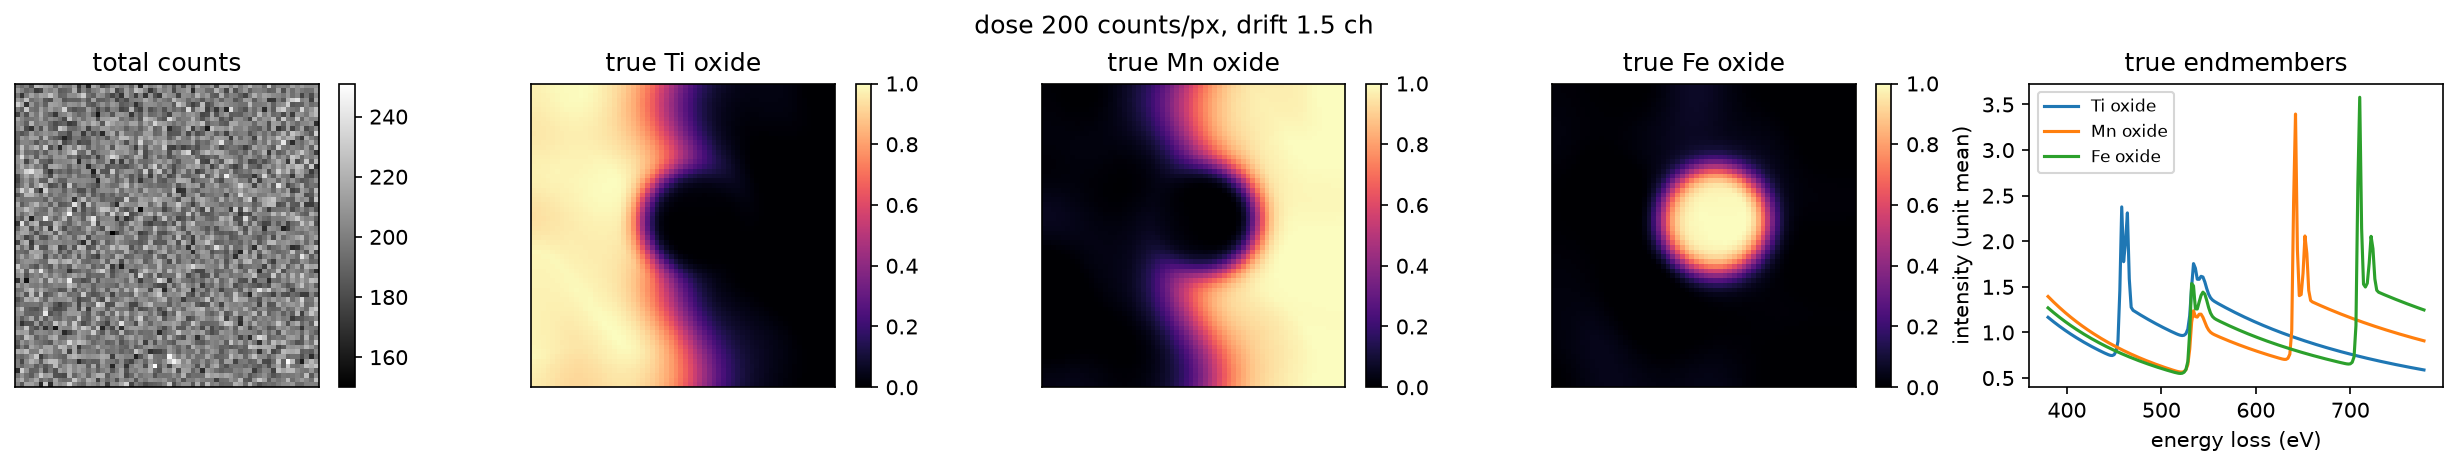

In [2]:
from eelsunmix.plots import plot_scene

plot_scene(scene, "nb_figs/scene.png")
Image("nb_figs/scene.png")

## Step 2: how many components?

On real data this is the first decision, and it is made without ground truth.
The PCA eigenvalue scree is the standard tool: signal components carry large
explained variance, noise components form a flat floor. Three phases plus
Poisson noise should give three components above the floor (drift blurs this
slightly, since a shifted spectrum is not exactly in the three-dimensional
span).

explained variance ratios: [0.03961 0.01552 0.0091  0.00813 0.00793 0.00788]


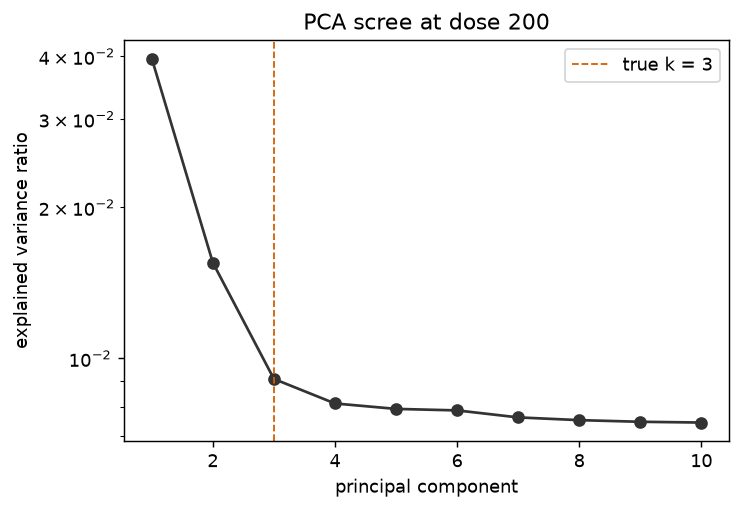

In [3]:
import matplotlib.pyplot as plt

from eelsunmix import pca_scree

evr = pca_scree(scene.flat, kmax=10)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(range(1, 11), evr, marker="o", color="#333333")
ax.axvline(3, color="#d55e00", ls="--", lw=1, label="true k = 3")
ax.set_xlabel("principal component")
ax.set_ylabel("explained variance ratio")
ax.set_title("PCA scree at dose 200")
ax.legend()
fig.savefig("nb_figs/scree.png", dpi=130, bbox_inches="tight")
plt.close(fig)
print("explained variance ratios:", np.round(evr[:6], 5))
Image("nb_figs/scree.png")

The mean spectrum dominates PC1; the scree drops after the third component
and flattens into the Poisson floor, so k = 3 is the defensible choice, and
it is what the rest of the notebook uses. The benchmark's `components` config
quantifies what happens when k is set wrong.

## Step 3: NMF

Non-negative matrix factorization is the workhorse: factor the cube into
non-negative spectra and non-negative loadings. Two honest caveats come with
it: the answer depends on initialization (the benchmark's `stability` config
measures that spread), and plain NMF does not know abundances should sum to
one. Here it runs with the deterministic nndsvda initialization.

In [4]:
from eelsunmix import match_endmembers, nmf_unmix

nmf_dec = nmf_unmix(scene.flat, k=3, seed=0)
nmf_match = match_endmembers(nmf_dec.spectra, scene.endmembers)
for t, sad in zip(nmf_match.true_index, nmf_match.sad_deg):
    print(f"{scene.names[t]:>9s}: spectral angle {sad:5.2f} deg")
print(f"mean: {nmf_match.mean_sad_deg:.2f} deg")

 Ti oxide: spectral angle 14.59 deg
 Mn oxide: spectral angle 23.26 deg
 Fe oxide: spectral angle 15.51 deg
mean: 17.78 deg


## Step 4: VCA

Vertex component analysis takes the geometric view: under the linear mixing
model, pixel spectra live in a simplex whose vertices are the endmembers, so
it hunts for the most extreme pixels. That works exactly when near-pure
pixels exist. In this scene the grain interiors are nearly pure but carry a
deliberate 8% mixing field, so VCA's endmembers are real pixel spectra,
Poisson noise included; abundances then come from non-negative least squares
with the sum-to-one constraint.

In [5]:
from eelsunmix import vca_unmix

vca_dec = vca_unmix(scene.flat, k=3, seed=0)
vca_match = match_endmembers(vca_dec.spectra, scene.endmembers)
for t, sad in zip(vca_match.true_index, vca_match.sad_deg):
    print(f"{scene.names[t]:>9s}: spectral angle {sad:5.2f} deg")
print(f"mean: {vca_match.mean_sad_deg:.2f} deg")

 Ti oxide: spectral angle 41.86 deg
 Mn oxide: spectral angle 44.09 deg
 Fe oxide: spectral angle 43.09 deg
mean: 43.01 deg


## Step 5: the constrained autoencoder

The autoencoder's decoder is the linear mixing model itself: the encoder MLP
maps each spectrum to k numbers, a softmax turns them into abundances
(non-negative, sum to one), and reconstruction multiplies them by a softplus
parametrized endmember matrix (non-negative). The network physically cannot
represent anything but a simplex mixture of non-negative spectra. Compared
with NMF it adds the sum-to-one constraint and denoises through the encoder;
like NMF it is non-convex, so its seed sensitivity is part of the benchmark,
not hidden.

 Ti oxide: spectral angle  7.23 deg
 Mn oxide: spectral angle  8.83 deg
 Fe oxide: spectral angle 12.24 deg
mean: 9.44 deg


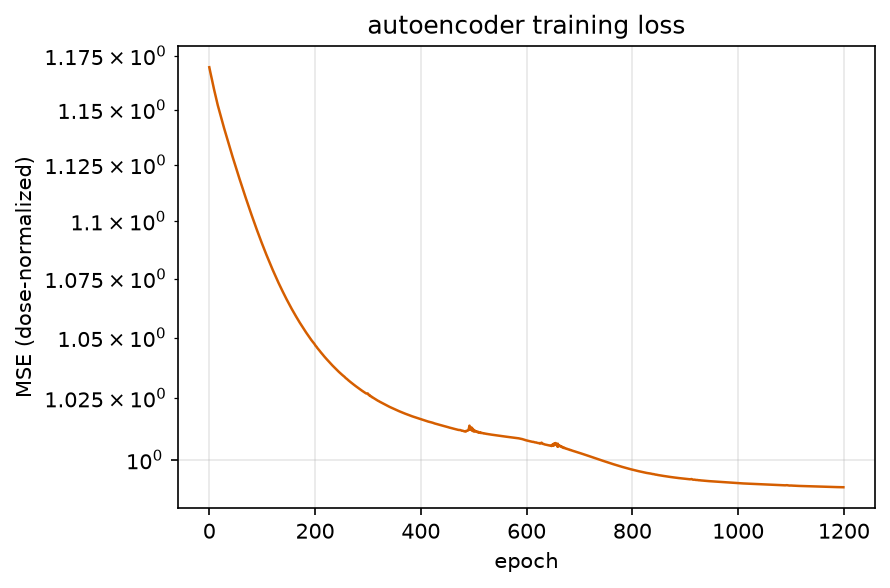

In [6]:
from eelsunmix import AETrainConfig, ae_unmix
from eelsunmix.plots import plot_loss_curve

ae_dec = ae_unmix(scene.flat, AETrainConfig(k=3, epochs=1200, seed=0))
plot_loss_curve(ae_dec.meta["loss_curve"], "nb_figs/loss.png")
ae_match = match_endmembers(ae_dec.spectra, scene.endmembers)
for t, sad in zip(ae_match.true_index, ae_match.sad_deg):
    print(f"{scene.names[t]:>9s}: spectral angle {sad:5.2f} deg")
print(f"mean: {ae_match.mean_sad_deg:.2f} deg")
Image("nb_figs/loss.png")

## Step 6: recovered endmembers and abundance maps against truth

The figure below is the whole story in one place: each recovered endmember
overlaid on the true spectrum (with its spectral angle), then the true
abundance maps and each method's matched maps.

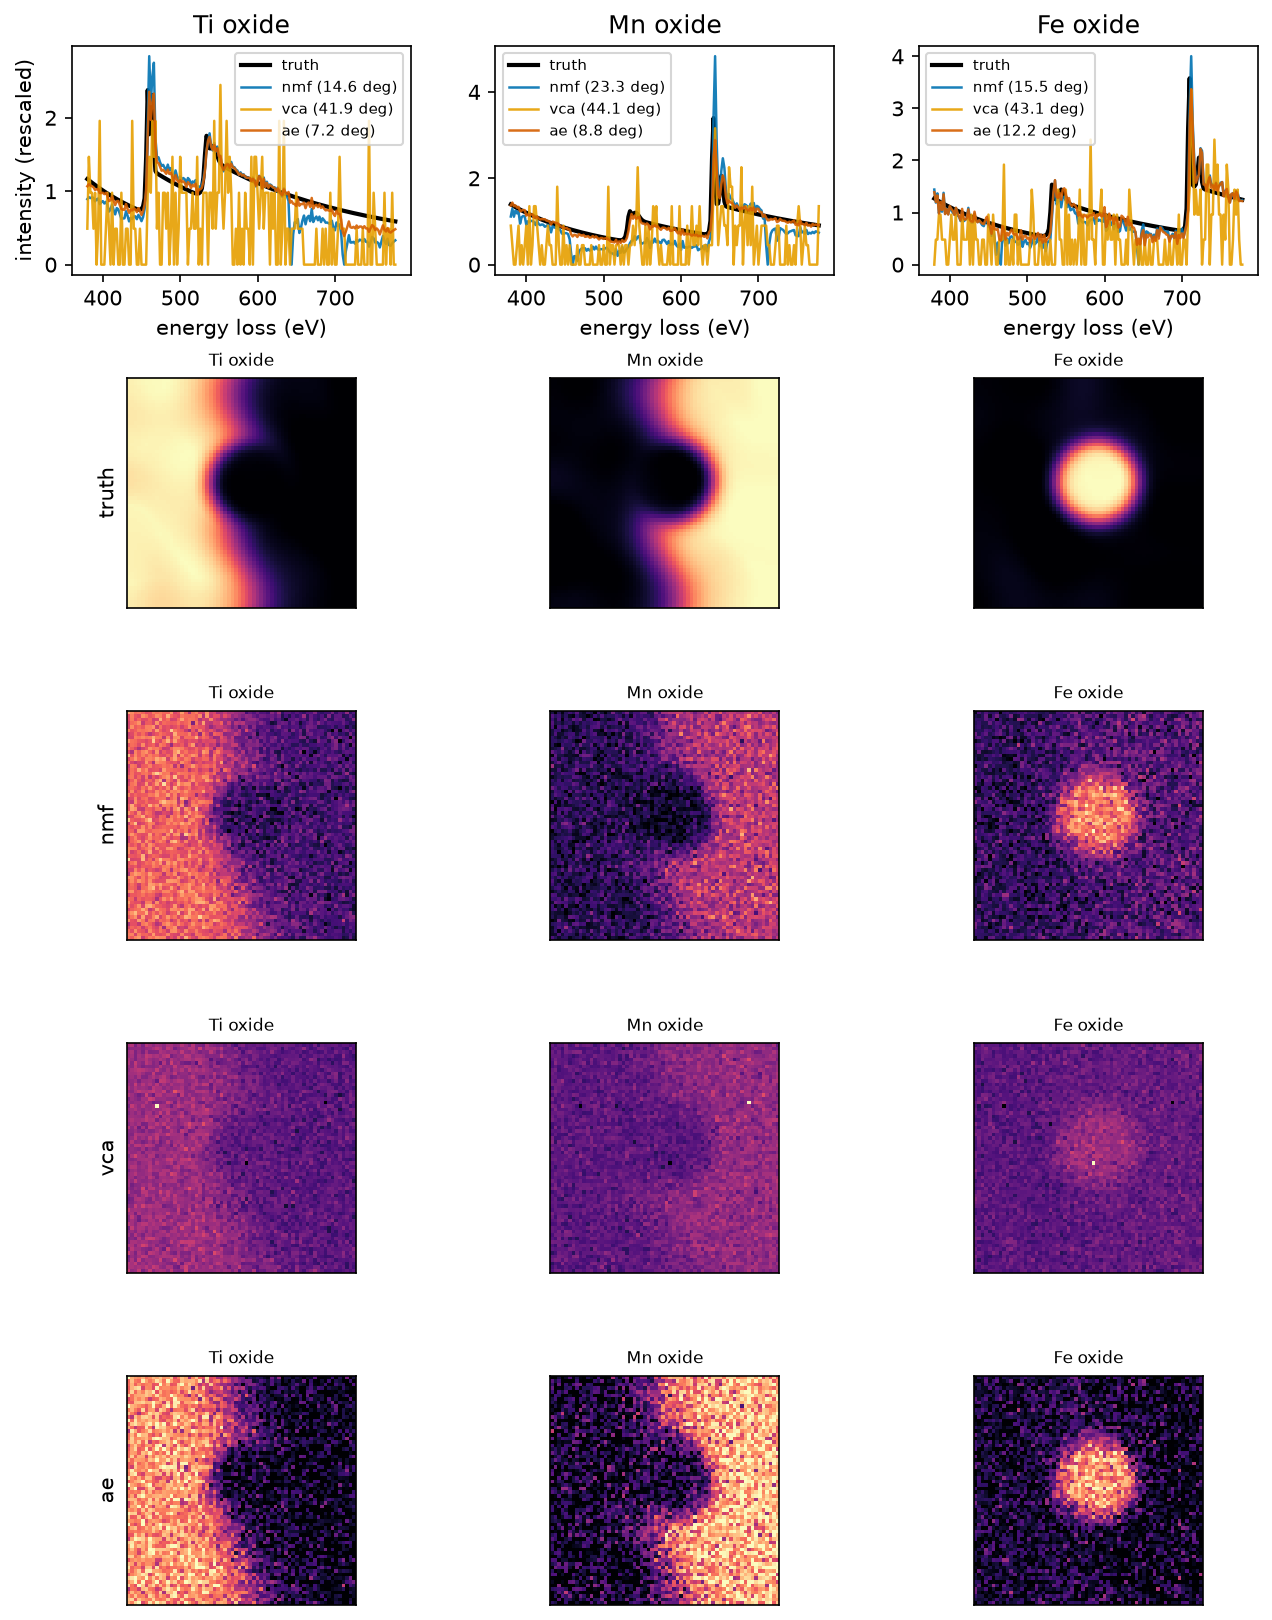

In [7]:
from eelsunmix.plots import plot_hero

plot_hero(scene, {"nmf": nmf_dec, "vca": vca_dec, "ae": ae_dec}, "nb_figs/hero.png")
Image("nb_figs/hero.png")

## Step 7: the final score

Spectral angle (degrees, after optimal matching; lower is better) for the
endmembers, RMSE for the sum-to-one abundance maps, and the largest principal
angle between the true endmember span and each method's component span.

In [8]:
from eelsunmix import abundance_rmse, subspace_error_deg

rows = []
for name, dec, match in (
    ("nmf", nmf_dec, nmf_match),
    ("vca", vca_dec, vca_match),
    ("ae", ae_dec, ae_match),
):
    rows.append(
        (
            name,
            match.mean_sad_deg,
            abundance_rmse(dec.abundances.T, scene.abundances, match),
            subspace_error_deg(scene.endmembers, dec.spectra),
        )
    )
print(f"{'method':>8s} {'SAD (deg)':>10s} {'abund RMSE':>11s} {'subspace (deg)':>15s}")
for name, sad, rmse, sub in rows:
    print(f"{name:>8s} {sad:10.2f} {rmse:11.4f} {sub:15.2f}")

  method  SAD (deg)  abund RMSE  subspace (deg)
     nmf      17.78      0.2627           33.52
     vca      43.01      0.3547           64.79
      ae       9.44      0.1639           30.10


## What to take away, and what not to

One seed at one dose is a demonstration, not a result. The committed
benchmark configs in `configs/` run the same comparison across doses (10 to
5000 counts), drift amplitudes, spectral-overlap levels, component counts,
and 10 seeds, with best-of-N variants for the initialization-sensitive
methods; `RESULTS.md` reads those numbers out and is the citable summary.

Everything here is simulation with a deliberately simple physical model: no
plural scattering, no spectrometer point-spread function, no channel gain
variation. The value of the synthetic route is exact ground truth, which
real spectrum images never have; absolute numbers will not transfer to any
particular instrument, but the method ranking and its failure modes
(initialization spread, overlap collapse, drift sensitivity) are the
transferable part.